# Echo cancellation

A frequently occurring distortion in speech telecommunication scenarios
is echoes, which have either an electric or acoustic cause. Electric
echoes appear in analogue networks at points of impedance mismatch.
Since a majority of telecommunication networks today are digital, such
electric echoes are mostly of historical interest and not discussed here
further. Acoustic echoes however is a problem which has become more
important, especially with the increasing use of teleconferencing
services. Such acoustic echoes appear when the speech of a person A is
played through the loudspeakers for a person B, such that the
loudspeaker sound is picked up by the microphone of person B and
transmitted back to person A. If the delay would be mere milliseconds,
then person A would perceive the feedback signal as reverberation, which
is *not* too disturbing (in some circumstances such an effect, known as
*side-talk*, could actually be a useful feature indicating that the
microphone is recording). However, typically the transmission delay is
above 100ms, such that the feedback is perceived as an echo, which is
usually highly disconcerting and disturbing. Even worse, sometimes the
acoustic echo signal completes the feedback loop and goes in a circle,
again and again. If the feedback signal is attenuated on each loop, then
the feedback slowly diminishes, but sometimes the feedback loop can
amplify the signal such that the signal quickly escalates up to the
physical limit of hardware or until the loudspeakers blow up. It is thus
clear that echoes must be avoided in real-life systems.

Fortunately, *echo cancellation* is a well-understood problem with
"standard" solutions available. In short, these methods are based on
estimating the acoustic room-impulse-response (RIR), filtering the
loudspeaker signal with the RIR to obtain an estimate of the acoustic
echo, and subtracting the estimated echo from the microphone signal.
Though it is a classic problem with off-the-shelf solutions available,
it remains a difficult problem. Central difficulties include:

-   The RIR is not stationary and must therefore be estimated on-line as
    an *adaptive filter*. The RIR changes whenever a door or window is
    opened or closed, furniture are moved or people move within the
    room, and even when the temperature of the room changes. Changes are
    even more rapid when using mobile, handheld or wearable devices,
    when the location of the device can change rapidly. In the worst
    case, the microphone and loudspeaker can be on different devices
    such that their acoustic distance can change rapidly.
-   When the RIR has a long tail, that is, when the room has a long
    reverberation, then the corresponding filters must be long, which
    increases *computational complexity*. Fast adaptation to changing
    RIRs also increases computational requirements.

Observe that echo *cancellation* methods refer to *subtracting* the
estimated echo from the microphone signal. In contrast, [noise
attenuation](Noise_attenuation) methods *multiply* the microphone
signal with a positive scalar, such that the output signal approximates
the echo-free signal. The essential difference is that multiplicative
methods generally estimate only the energy/magnitude of the signal,
while subtractive methods try to match both magnitude and phase. The
benefit of subtractive methods is that the output quality is generally
better since the removal-method matches the physical process which
creates the signal. Multiplicative methods however are much more robust
than subtractive methods; in particular, if the phase is incorrectly
estimated, then a subtractive method can *increase* the amount of noise
in a signal. In the worst case, an echo canceller poorly matched to the
room response can generate a catastrophic feedback loop, whereas
multiplicative methods can be designed to never increase the amount of
noise.

*Echo suppression* methods use this insight to remove acoustic echo with
a multiplicative method similar to that of spectral subtraction or
Wiener filtering used in noise attenuation.


## Echo cancellation solutions

As it is mentioned above, the problem that echo cancellation needs to
solve is the effect of the room in the path from a loudspeaker to the
microphone used in the communication. This means that the signal played
by the loudspeaker enters the system with a certain delay and multiple
echo paths (Room impulse response). From now on, we will refer to the
received signal played by the loudspeaker as far-end (*x(n)*), and the
useful speech signal from the user will be called near-end signal
(*s(n)*). The mixture recorded by the microphone that would be sent to
the other end of the call can be represented as:

$$ d(n) = s(n) + h(n)*x(n) + v(n) $$

where *v(n)* represents additive noise in the scene and, for simplicity,
will be considered part of *s(n)*. The effect of the room on the far-end
signal can be modelled as an FIR filter *h(n)*, added to the far-end
signal using a convolution. The idea of echo cancellation is to find an
estimation of this FIR filter, and applying it to the received far-end
signal, we can then subtract it from *d(n)* to extract the useful
near-end signal.

The estimation of the echo path model is done by *minimizing* the *mean
square error* (MMSE) between the recorded signal and the estimated
filtered far-end, assuming that s(n) is not present. However, only one
estimation is not possible due to multiple factors.

1.  The echo path is unknown at the beginning of the communication,
    additionally, any changes in the echo path can be catastrophic in
    the estimation.
2.  The non-stationariety of the speech signal makes the estimation of
    the echo path a complex task.
3.  It is very likely that *s(n)* is present in the recorded signal,
    causing the estimation to be flawed (Double-talk).

These three issues require a continuous monitoring of the quality of the
estimation and the filter must be periodically updated in order to
accurately represent the echo path. For that reason the MMSE method must
be calculated iteratively as we receive more information from the
far-end and recorded signals. The most popular algorithm to calculate
this adaptive filter is Least Mean Squares (LMS) and its multiple
variants. The expression to minimise is:

$$ MMSE = min \|d(n) - \hat{h}(n)*x(n)\|^2 $$

The objective is to find the coefficients of the estimated filter that
minimise the previous equation, and a simple depiction of the iterative
LMS algorithm used to update the filter can be divided in three steps:

-   Estimate the recorded echo signal:

$$ \hat{y}(n) = \sum_{i} \hat{h}(n-i)*x(n-i) $$

-   Estimate the error:

$$ e(n) = d(n) - \hat{y}(n) $$

-   Update the filter weights:

$$ \hat{h}_{t+1}(n) = \hat{h}_{t}(n) + \mu \cdot e^H(n) \cdot x(n) $$

The term *μ* represents the learning rate of the algorithm. Higher
values will make the algorithm converge faster, but might converge to a
bigger error value, while smaller learning rate will converge slower and
it might not be able to follow the changes in the echo path. It has been
proven that an adaptive learning rate provides the best results and most
modifications on this method, focus on handling an adaptive learning
rate according to the required specifications. As we can see in the
second equation, the estimation error of the adaptation algorithm is
also the signal that will be used as output and that will contain the
corresponding *s(n)* in an optimal case.

This first approach of the LMS adaptive filter is proposed to be applied
on the time domain of the audio signal. If the filter updates on every
sample of the received audio signal, accurately modelling a room impulse
response will require a filter of a few thousand samples. Updating the
filter on every new sample becomes computationally expensive, and for
these reasons other methods are proposed based on this approach:

-   BlockLMS: Reduce the rate of updates in the algorithm, such that the
    update is only applied once every certain number of samples can help
    considerably reduce the complexity of the algorithm. However, the
    block processing can affect the convergence of the algorithm and
    reduce its responsiveness.
-   Frequency Domain Adaptive Filters (FDAF): The simplest case of FDAF
    consists in converting the audio signal to the frequency domain
    using an STFT, and then apply an independent LMS filter on each of
    the frequency components of the signal. This allows to represent
    the echo path with a much smaller amount of samples. Considering the
    algorithm with quadratic complexity, it is preferable to have many
    short filters than having just a long one.

Finally, as we mention above, the main problem that adaptive filters
face in real-life communication applications is double talk. In a common
interaction between two people, it is very likely that both speakers are
active at the same time. In the echo cancellation framework, that means
that both far-end signal *y(n)* and near-end *s(n)* will be present in
the mixture. As the adaptive filter tries to minimize the error between
the far-end signal and the recorded one, in the presence of double-talk
the filter will likely diverge and add distortion to the near-end signal
instead of reducing the echo feedback.

To reduce the effect of double-talk in the adaptation process, it is
important to detect when double-talk starts and stop the adaptation.
Assuming that the filter had converged before the double-talk segment,
then the far-end signal should still be removed, while the near-end
speaker would pass through. Many methods have been presented to control
the learning rate of the adaptative filter depending on the detected
double-talk, but most of them are based on three main ideas:

-   Energy based detection (Geigel detector):
    -   This detector assumes that, if the energy ratio between the
        far-end signal and the recorded one will remain almost constant
        until an additional voice is added from the near-end signal.
        When the ratio between far-end and recorded signals changes, we
        can assume that there is double-talk.
    -   It is a very simple method that barely adds any computational
        complexity to the system.
    -   The detector assumes that the echo level is clearly different
        than the near-end speech. Therefore, this method is highly
        influenced by noise and signal misalignment.
    -   The method also requires to be tuned for each specific
        configuration and changes in the echo path during communication
        might trigger the double-talk detection.
-   Normalized Cross-Correlation (NCC):
    -   This method measures the correlation between the input *d(n)*
        and the processed error signal *e(n)*. When *s(n)* is present
        in *d(n)*, the correlation between term will be higher due to
        *s(n)* remaining present in the error signal if $\hat{y}(n)$
        was estimated correctly.
    -   Alternatively, there is no double-talk if *s(n)* is not present,
        and assuming a converged filter, *e(n)* will only contain noise,
        thus resulting in a lower correlation.
    -   This method is more robust to noise than the energy levels.
    -   The value of NCC will be close to 1 when double-talk is present,
        and 0 when it is not. Therefore, the NCC can be used as a
        scaling factor for the learning rate.

$$ NCC = \frac{\sigma^{2}_{ed}(n)}{\sigma_{e}(n)\sigma_{d}(n)} $$

$$ \sigma^{2}_{x} = E[xx^H] $$

$$ \sigma^{2}_{x}(n) =
\lambda\sigma^{2}_{x}(n - 1) + (1 - \lambda)\sigma^{2}_{x} $$

$$ \mu_{NCC} = (1 - NCC)\mu_{max} $$

-   Two-path Echo Cancellation:
    -   Two filters, background and foreground, process the echo signal
        simultaneously. The background filter is continuously adapting
        on every step, while the foreground one remains fixed. A control
        module then decides if there is double-talk and the better
        solution is to update the coefficients or keep them unmodified
        based on the output of the background and foreground filters.
    -   It is the most robust of the presented methods.
    -   Requires additional computational complexity, as the far-end
        signal needs to be filtered twice before deciding if there is
        double-talk.


The acoustic feedback loop in telecommunication applications.

![echocancellation.png](attachments/175509295.png)

Model of the echo path and estimated filter

![image](attachments/203126383.png)

Feedback loop for echo cancellation

![image2](attachments/203126386.png)

Two-path echo cancellation model

![twopath](attachments/203126388.png)


# Demonstration: acoustic echo cancellation

Let's build a small, fully synthetic acoustic echo scenario and apply the
NLMS (normalized LMS) adaptive filter described above to cancel it, so
that we can both see and hear the whole process end to end.

We construct:

-   a far-end signal $x(n)$ -- a speech recording played out of the
    loudspeaker,
-   a near-end signal $s(n)$ -- a *different* speech recording, active
    only during the second half of the clip, so that the first half is
    single-talk (far-end only) and the second half is double-talk (both
    active at once),
-   a synthetic room impulse response $h(n)$ -- an exponentially
    decaying random sequence, standing in for the acoustic path from the
    loudspeaker to the microphone,

and mix them into the microphone signal $d(n) = s(n) + h(n)*x(n) + v(n)$
exactly as in the equation above, with $v(n)$ a small amount of
background noise.


In [1]:
import numpy as np
import scipy.signal
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython

sample_rate = 16000

# Far-end (loudspeaker) and near-end (local speaker) signals: two
# different recordings so that they are statistically independent, as
# assumed by the adaptive filter derivation above.
far_end, _ = librosa.load("sounds/enhancement_test_16k.wav", sr=sample_rate)
near_end_utterance, _ = librosa.load("sounds/sample-speech-16k.wav", sr=sample_rate)

# Total demo length and the time at which the near-end speaker starts
# talking, splitting the clip into a single-talk half and a double-talk
# half.
duration_s = 8.0
double_talk_start_s = 5.0

num_samples = int(duration_s * sample_rate)
double_talk_start = int(double_talk_start_s * sample_rate)

far_end = far_end[:num_samples]
near_end = np.zeros(num_samples)
copy_length = min(len(near_end_utterance), num_samples - double_talk_start)
near_end[double_talk_start:double_talk_start + copy_length] = near_end_utterance[:copy_length]

# A synthetic room impulse response: an exponentially decaying random
# sequence with a unit direct path, representing a small room with a
# reverberation time on the order of tens of milliseconds.
rng = np.random.default_rng(0)
rir_length = 400  # 25ms at 16kHz
decay = np.exp(-np.arange(rir_length) / sample_rate / 0.015)
room_impulse_response = rng.standard_normal(rir_length) * decay
room_impulse_response[0] = 1.0
room_impulse_response /= np.sqrt(np.sum(room_impulse_response ** 2))

echo = scipy.signal.fftconvolve(far_end, room_impulse_response)[:num_samples]
background_noise = 0.001 * rng.standard_normal(num_samples)
microphone_signal = near_end + echo + background_noise


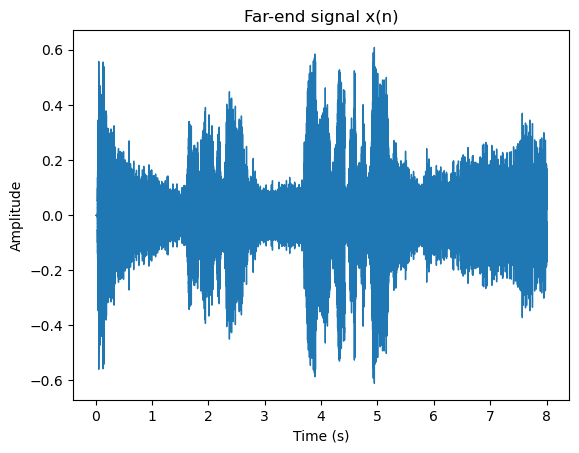

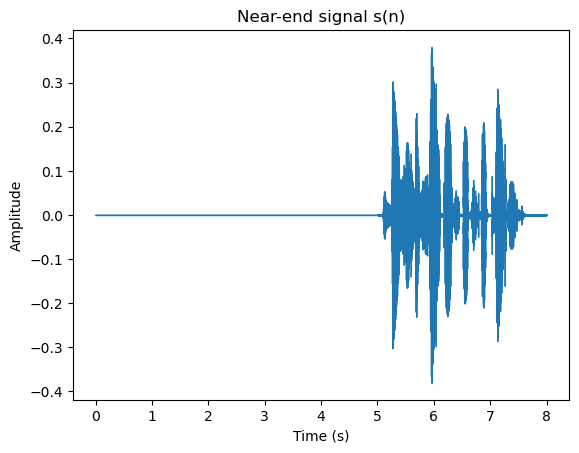

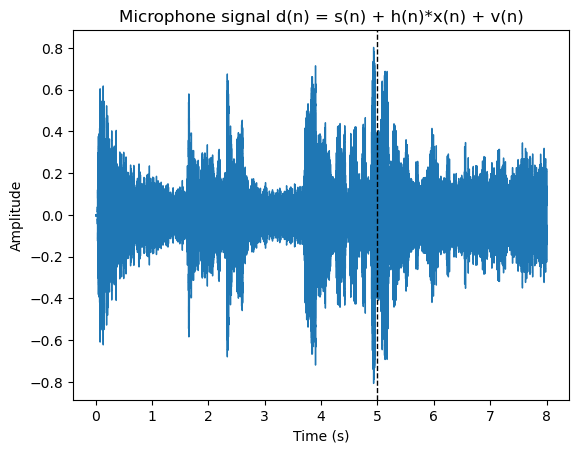

In [2]:
librosa.display.waveshow(far_end, sr=sample_rate)
plt.title("Far-end signal x(n)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
IPython.display.display(IPython.display.Audio(far_end, rate=sample_rate))

librosa.display.waveshow(near_end, sr=sample_rate)
plt.title("Near-end signal s(n)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
IPython.display.display(IPython.display.Audio(near_end, rate=sample_rate))

librosa.display.waveshow(microphone_signal, sr=sample_rate)
plt.title("Microphone signal d(n) = s(n) + h(n)*x(n) + v(n)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.axvline(double_talk_start_s, color="black", linestyle="--", linewidth=1)
plt.show()
IPython.display.display(IPython.display.Audio(microphone_signal, rate=sample_rate))


Notice how the echo is clearly audible throughout $d(n)$, and how the
near-end speaker (starting at the dashed line) is buried underneath it.

We now implement the LMS update rule given above, with one standard
addition: we normalize the step size $\mu$ by the energy of the far-end
samples currently in the filter memory. This *normalized LMS* (NLMS)
variant is what most practical implementations use, since it keeps the
adaptation stable regardless of the input signal's level -- exactly the
kind of adaptive-learning-rate modification mentioned above.

To isolate the effect of double-talk, we run the adaptive filter twice
on the same signals:

-   once with an (idealised) double-talk detector that freezes the
    filter the moment the near-end speaker starts, matching the
    assumption made above ("assuming that the filter had converged
    before the double-talk segment"),
-   once that keeps adapting blindly throughout, ignoring double-talk
    entirely.


In [3]:
def nlms_echo_cancel(far_end, microphone_signal, filter_length, step_size=0.3, freeze_at=None, eps=1e-6):
    """Normalized LMS echo cancellation.

    Returns the error signal e(n) (the echo-cancelled output) and the
    final estimated impulse response. Adaptation stops at sample
    `freeze_at` if given, otherwise it continues for the whole signal.
    """
    num_samples = len(microphone_signal)
    estimated_rir = np.zeros(filter_length)
    error_signal = np.zeros(num_samples)
    padded_far_end = np.concatenate([np.zeros(filter_length - 1), far_end])

    for n in range(num_samples):
        far_end_window = padded_far_end[n:n + filter_length][::-1]
        echo_estimate = np.dot(estimated_rir, far_end_window)
        error_signal[n] = microphone_signal[n] - echo_estimate

        if freeze_at is None or n < freeze_at:
            normalization = np.dot(far_end_window, far_end_window) + eps
            estimated_rir += step_size * error_signal[n] * far_end_window / normalization

    return error_signal, estimated_rir


filter_length = rir_length

cancelled_with_detector, estimated_rir = nlms_echo_cancel(
    far_end, microphone_signal, filter_length, freeze_at=double_talk_start)

cancelled_without_detector, _ = nlms_echo_cancel(
    far_end, microphone_signal, filter_length, freeze_at=None)


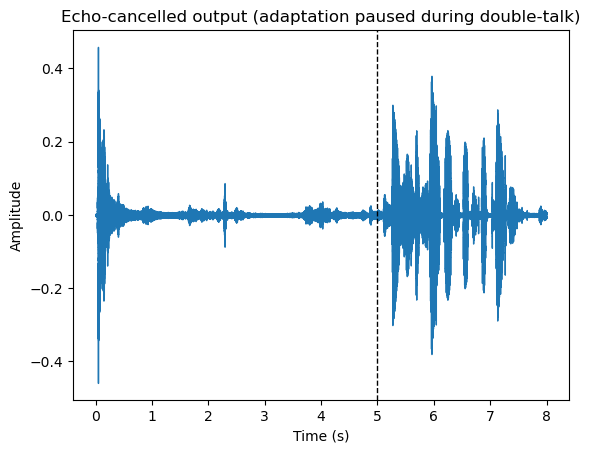

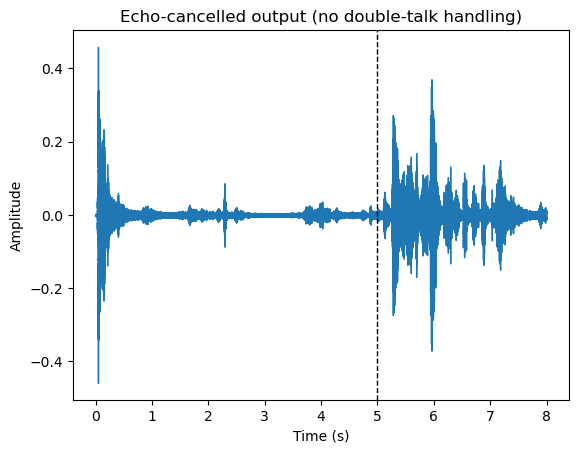

In [4]:
librosa.display.waveshow(cancelled_with_detector, sr=sample_rate)
plt.title("Echo-cancelled output (adaptation paused during double-talk)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.axvline(double_talk_start_s, color="black", linestyle="--", linewidth=1)
plt.show()
IPython.display.display(IPython.display.Audio(cancelled_with_detector, rate=sample_rate))

librosa.display.waveshow(cancelled_without_detector, sr=sample_rate)
plt.title("Echo-cancelled output (no double-talk handling)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.axvline(double_talk_start_s, color="black", linestyle="--", linewidth=1)
plt.show()
IPython.display.display(IPython.display.Audio(cancelled_without_detector, rate=sample_rate))


The echo is clearly gone from the first output, with the near-end speaker
passing through once they start talking, while the second output starts
to pick up an audible echo and distortion again after the double-talk
begins -- exactly the divergence problem described above. We can also
compare the true room impulse response to the one estimated by the
(frozen) adaptive filter:


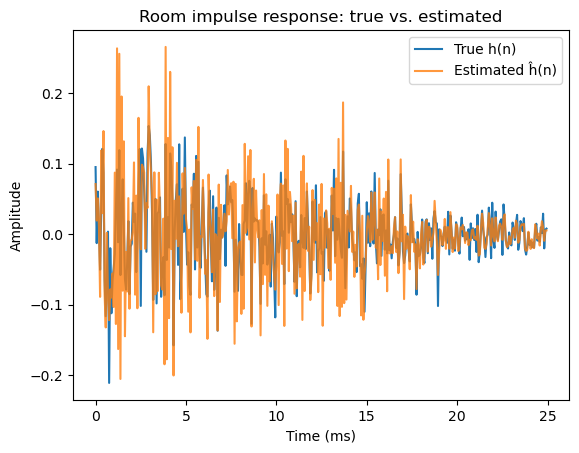

In [5]:
time_axis_ms = np.arange(rir_length) / sample_rate * 1000

plt.plot(time_axis_ms, room_impulse_response, label="True h(n)")
plt.plot(time_axis_ms, estimated_rir, label="Estimated ĥ(n)", alpha=0.8)
plt.title("Room impulse response: true vs. estimated")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


Finally, let's quantify the echo attenuation over time using the **Echo
Return Loss Enhancement (ERLE)**, the standard metric for echo
cancellation performance:

$$ \text{ERLE}(n) = 10 \log_{10} \frac{E[(h(n)*x(n))^2]}{E[(e(n) - s(n))^2]} $$

computed here over short, non-overlapping windows, comparing the two
runs from above.


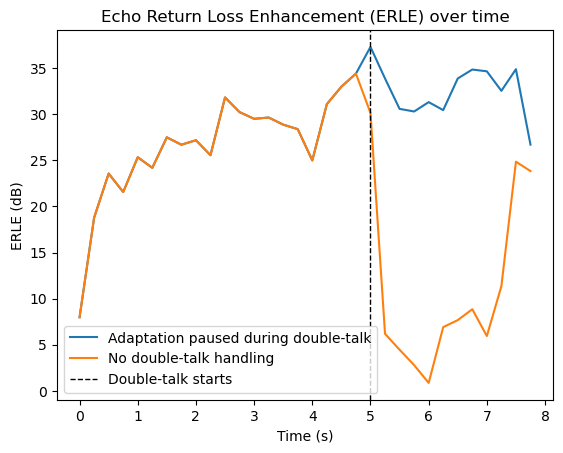

Mean ERLE after convergence, single-talk:             28.7 dB
Mean ERLE during double-talk, with detector:          32.6 dB
Mean ERLE during double-talk, without detector:       11.2 dB


In [6]:
def windowed_erle(error_signal, echo, near_end, window_length):
    residual = error_signal - near_end
    num_windows = len(error_signal) // window_length
    erle = np.zeros(num_windows)
    for i in range(num_windows):
        window = slice(i * window_length, (i + 1) * window_length)
        echo_energy = np.sum(echo[window] ** 2)
        residual_energy = np.sum(residual[window] ** 2)
        erle[i] = 10 * np.log10((echo_energy + 1e-12) / (residual_energy + 1e-12))
    return erle


window_length = int(0.25 * sample_rate)  # 250ms windows
erle_with_detector = windowed_erle(cancelled_with_detector, echo, near_end, window_length)
erle_without_detector = windowed_erle(cancelled_without_detector, echo, near_end, window_length)
time_axis_s = np.arange(len(erle_with_detector)) * window_length / sample_rate

plt.plot(time_axis_s, erle_with_detector, label="Adaptation paused during double-talk")
plt.plot(time_axis_s, erle_without_detector, label="No double-talk handling")
plt.axvline(double_talk_start_s, color="black", linestyle="--", linewidth=1, label="Double-talk starts")
plt.title("Echo Return Loss Enhancement (ERLE) over time")
plt.xlabel("Time (s)")
plt.ylabel("ERLE (dB)")
plt.legend()
plt.show()

print(f"Mean ERLE after convergence, single-talk:            "
      f"{np.mean(erle_with_detector[time_axis_s < double_talk_start_s][4:]):5.1f} dB")
print(f"Mean ERLE during double-talk, with detector:         "
      f"{np.mean(erle_with_detector[time_axis_s >= double_talk_start_s]):5.1f} dB")
print(f"Mean ERLE during double-talk, without detector:      "
      f"{np.mean(erle_without_detector[time_axis_s >= double_talk_start_s]):5.1f} dB")


As the plot shows, both runs converge similarly during the single-talk
phase, reaching a stable echo attenuation of around 25-30dB. Once
double-talk begins, the run with an (idealised) double-talk detector
keeps that same level of echo attenuation, since its filter is simply
frozen at its converged estimate. The run without any double-talk
handling, however, immediately starts to diverge: the near-end speech
gets misinterpreted as an error to correct for, the filter drifts away
from the true room impulse response, and both the echo attenuation and
the near-end signal quality degrade -- audibly so in the example above.
This is precisely the failure mode that motivates the Geigel, NCC, and
two-path double-talk detection methods described earlier in this
section; here we simply used an oracle (the known start time of the
near-end utterance) to isolate and illustrate the effect in isolation.
